# LLM Complete Benchmark

In [1]:
!pip -q install datasets openai pandas numpy tqdm matplotlib seaborn plotly

/bin/bash: /home/sasank-v/anaconda3/envs/ml/lib/libtinfo.so.6: no version information available (required by /bin/bash)


In [2]:
import os
import re
import json
import time
from pathlib import Path
from datetime import datetime
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from datasets import load_dataset, Dataset, DatasetDict
from openai import OpenAI

In [ ]:
# OpenAI-compatible API settings
api_url = os.getenv("OPENAI_BASE_URL", "https://llm.ipropel.co.in/v1")
llm_key = os.getenv("OPENAI_API_KEY", "")
models_to_eval = [
    "openai/gpt-oss-20b",
]

# Dedicated OpenAI-compatible embedding client settings
embedding_base_url = os.getenv("EMBEDDING_BASE_URL", api_url)
embedding_api_key = os.getenv("EMBEDDING_API_KEY", llm_key)
embedding_model = os.getenv("EMBEDDING_MODEL", "text-embedding-3-small")
open_semantic_threshold = float(os.getenv("OPEN_SEMANTIC_THRESHOLD", "0.80"))

# Hugging Face token for gated datasets (SciEx, TuringQ may require this)
hf_token = os.getenv("HF_TOKEN", "hf_xxxyyyzz")
if hf_token:
    os.environ["HF_TOKEN"] = hf_token

# Local CS-Bench path (already used previously in this workspace)
cs_bench_path = "../../datasets/benchmark/CS Bench/cs-bench.jsonl"

# Evaluation runtime controls
max_questions_per_dataset = None  # set to int for quick tests
temperature = 0.0
max_tokens_mcq = 32
max_tokens_open = 256
request_timeout = 90
max_retries = 3
retry_sleep_seconds = 2

# assert llm_key, "Set OPENAI_API_KEY (or assign llm_key directly in this cell)."
client = OpenAI(api_key=llm_key, base_url=api_url)
embedding_client = OpenAI(api_key=embedding_api_key, base_url=embedding_base_url)

print(f"API URL: {api_url}")
print(f"Models: {models_to_eval}")
print(f"Embedding URL: {embedding_base_url}")
print(f"Embedding model: {embedding_model}")
print(f"Open-ended semantic threshold: {open_semantic_threshold}")
print(f"CS-Bench path: {cs_bench_path}")
print("HF token set:", bool(hf_token))

API URL: https://llm.ipropel.co.in/v1
Models: ['openai/gpt-oss-20b']
Embedding URL: https://llm.ipropel.co.in/v1
Embedding model: text-embedding-3-small
Open-ended semantic threshold: 0.8
CS-Bench path: ../../datasets/benchmark/CS Bench/cs-bench.jsonl
HF token set: True


In [4]:
def safe_load_hf_dataset(dataset_id: str, token: str = "") -> Optional[DatasetDict]:
    try:
        kwargs = {"token": token} if token else {}
        ds = load_dataset(dataset_id, **kwargs)
        print(f"Loaded {dataset_id}: splits={list(ds.keys())}")
        return ds
    except Exception as exc:
        print(f"Could not load {dataset_id}: {exc}")
        return None

def load_cs_bench_jsonl(path: str) -> List[Dict[str, Any]]:
    p = Path(path)
    if not p.exists():
        print(f"CS-Bench file not found: {path}")
        return []
    rows: List[Dict[str, Any]] = []
    with p.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    print(f"Loaded CS-Bench: {len(rows)} rows")
    return rows

def first_existing(d: Dict[str, Any], keys: List[str], default: Any = None) -> Any:
    for k in keys:
        if k in d and d[k] is not None:
            return d[k]
    return default

def normalize_ws(text: Any) -> str:
    return re.sub(r"\s+", " ", str(text).strip())

def normalize_text(text: Any) -> str:
    return normalize_ws(text).lower()

def to_letter(idx: int) -> str:
    letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    return letters[idx] if 0 <= idx < len(letters) else ""

def parse_options(raw: Any) -> List[str]:
    if raw is None:
        return []
    if isinstance(raw, list):
        out = []
        for item in raw:
            if isinstance(item, dict):
                val = first_existing(item, ["text", "content", "value", "option"], "")
                out.append(normalize_ws(val))
            else:
                out.append(normalize_ws(item))
        return [x for x in out if x]
    if isinstance(raw, dict):
        keys = sorted(raw.keys())
        return [normalize_ws(raw[k]) for k in keys if normalize_ws(raw[k])]
    return []

def normalize_mcq_answer(raw_answer: Any, options: List[str]) -> str:
    ans = normalize_ws(raw_answer)
    if not ans:
        return ""
    if ans.isdigit():
        idx = int(ans)
        if len(options) > idx >= 0:
            return to_letter(idx)
    upper = ans.upper()
    for ch in upper:
        if ch in "ABCDEFGHIJKLMNOPQRSTUVWXYZ":
            return ch
    for idx, opt in enumerate(options):
        if normalize_text(opt) == normalize_text(ans):
            return to_letter(idx)
    return ans

def infer_domain_label(row: Dict[str, Any]) -> str:
    label = first_existing(row, [
        "Discipline", "discipline",
        "Domain", "domain",
        "Subject", "subject",
        "Category", "category",
        "Topic", "topic",
        "Field", "field",
    ], "")
    return normalize_ws(label)

def is_cs_label(label: str) -> bool:
    l = normalize_text(label)
    if not l:
        return False
    cs_terms = [
        "computer science",
        "cs",
        "theory of computation",
        "algorithms",
        "data structures",
        "software",
        "programming",
    ]
    return any(term in l for term in cs_terms)

def build_mmlu_pro_row(row: Dict[str, Any], idx: int) -> Optional[Dict[str, Any]]:
    # Explicit schema: question_id, question, options, answer, answer_index, cot_content, category, src
    question = normalize_ws(row.get("question", ""))
    if not question:
        return None

    options = parse_options(row.get("options", []))
    if not options:
        return None

    answer_index = row.get("answer_index", None)
    answer_letter = ""
    if isinstance(answer_index, int) and answer_index >= 0:
        answer_letter = to_letter(answer_index)

    answer_text = normalize_ws(row.get("answer", ""))
    gold = answer_letter or normalize_mcq_answer(answer_text, options)
    if not gold:
        return None

    domain = normalize_ws(row.get("category", "Computer Science"))
    meta = {
        "question_id": row.get("question_id"),
        "src": row.get("src", ""),
        "cot_content": row.get("cot_content", ""),
    }

    return {
        "uid": f"mmlu_pro_cs-{idx}",
        "dataset": "mmlu_pro_cs",
        "domain": domain,
        "format": "Multiple-choice",
        "question": question,
        "options": options,
        "gold": gold,
        "meta": meta,
        "raw": row,
    }

def build_turingq_row(row: Dict[str, Any], idx: int) -> Optional[Dict[str, Any]]:
    # Explicit schema: Question, Answer, Category, Difficulty, Source, University, Type
    question = normalize_ws(row.get("Question", ""))
    answer = normalize_ws(row.get("Answer", ""))
    if not question or not answer:
        return None

    domain = normalize_ws(row.get("Category", "Computer Science"))
    q_type = normalize_ws(row.get("Type", ""))
    q_format = "Open-ended"

    meta = {
        "difficulty": normalize_ws(row.get("Difficulty", "")),
        "source": normalize_ws(row.get("Source", "")),
        "university": normalize_ws(row.get("University", "")),
        "type": q_type,
    }

    return {
        "uid": f"turingq-{idx}",
        "dataset": "turingq",
        "domain": domain,
        "format": q_format,
        "question": question,
        "options": [],
        "gold": answer,
        "meta": meta,
        "raw": row,
    }

def build_generic_row(
    source_name: str,
    row: Dict[str, Any],
    idx: int,
    force_domain: Optional[str] = None,
    force_format: Optional[str] = None,
) -> Optional[Dict[str, Any]]:
    question = first_existing(row, [
        "Question", "question", "prompt", "problem", "query", "instruction", "stem"
    ], "")
    question = normalize_ws(question)
    if not question:
        return None

    options = first_existing(row, ["options", "choices", "candidates", "Options"], None)
    options_list = parse_options(options)

    if not options_list:
        letter_keys = [k for k in ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"] if k in row]
        if letter_keys:
            options_list = [normalize_ws(row[k]) for k in letter_keys if normalize_ws(row[k])]

    raw_answer = first_existing(row, [
        "Answer", "answer", "target", "label", "correct_answer", "solution", "gold", "output"
    ], "")

    domain = force_domain or infer_domain_label(row) or source_name
    q_format = force_format or ("Multiple-choice" if options_list else "Open-ended")
    gold = normalize_mcq_answer(raw_answer, options_list) if options_list else normalize_ws(raw_answer)

    if not gold:
        return None

    return {
        "uid": f"{source_name}-{idx}",
        "dataset": source_name,
        "domain": domain,
        "format": q_format,
        "question": question,
        "options": options_list,
        "gold": gold,
        "meta": {},
        "raw": row,
    }

In [5]:
# Load datasets
mmlu_pro_ds = safe_load_hf_dataset("TIGER-Lab/MMLU-Pro", token=hf_token)
sciex_ds = safe_load_hf_dataset("tuanh23/SciEx", token=hf_token)
turingq_ds = safe_load_hf_dataset("llm-lab/TuringQ", token=hf_token)
cs_bench_rows = load_cs_bench_jsonl(cs_bench_path)

def flatten_hf_splits(ds: Optional[DatasetDict]) -> List[Dict[str, Any]]:
    rows: List[Dict[str, Any]] = []
    if ds is None:
        return rows
    for split_name in ds.keys():
        split_rows = ds[split_name].to_list()
        for row in split_rows:
            row = dict(row)
            row["_split"] = split_name
            rows.append(row)
    return rows

mmlu_rows = flatten_hf_splits(mmlu_pro_ds)
sciex_rows = flatten_hf_splits(sciex_ds)
turingq_rows = flatten_hf_splits(turingq_ds)

print("Raw row counts:")
print("MMLU-Pro:", len(mmlu_rows))
print("SciEx:", len(sciex_rows))
print("TuringQ:", len(turingq_rows))
print("CS-Bench:", len(cs_bench_rows))

# Strict CS-only filter for MMLU-Pro and SciEx as requested
mmlu_cs_rows = [r for r in mmlu_rows if normalize_text(str(r.get("category", ""))) == "computer science"]
sciex_cs_rows = [r for r in sciex_rows if is_cs_label(infer_domain_label(r))]

print("Filtered row counts (Computer Science only where requested):")
print("MMLU-Pro (CS only):", len(mmlu_cs_rows))
print("SciEx (CS only):", len(sciex_cs_rows))
print("TuringQ (all):", len(turingq_rows))
print("CS-Bench (all):", len(cs_bench_rows))

if mmlu_rows and not mmlu_cs_rows:
    print("Warning: MMLU-Pro loaded but no rows with category == 'Computer Science'.")
if sciex_rows and not sciex_cs_rows:
    print("Warning: SciEx loaded but no Computer Science rows matched domain labels.")

unified_rows: List[Dict[str, Any]] = []

for i, row in enumerate(mmlu_cs_rows):
    u = build_mmlu_pro_row(row, i)
    if u:
        unified_rows.append(u)

for i, row in enumerate(sciex_cs_rows):
    u = build_generic_row("sciex_cs", row, i, force_domain="Computer Science")
    if u:
        unified_rows.append(u)

for i, row in enumerate(turingq_rows):
    u = build_turingq_row(row, i)
    if u:
        unified_rows.append(u)

for i, row in enumerate(cs_bench_rows):
    u = build_generic_row("cs_bench", row, i, force_domain="Computer Science")
    if u:
        unified_rows.append(u)

if max_questions_per_dataset is not None:
    trimmed: List[Dict[str, Any]] = []
    for dname in ["mmlu_pro_cs", "sciex_cs", "turingq", "cs_bench"]:
        subset = [r for r in unified_rows if r["dataset"] == dname][:max_questions_per_dataset]
        trimmed.extend(subset)
    unified_rows = trimmed

eval_df = pd.DataFrame(unified_rows)
print(f"Unified evaluation rows: {len(eval_df)}")
display(eval_df.groupby(["dataset", "format"]).size().rename("count").reset_index())

# Quick schema sanity previews
if not eval_df.empty:
    preview_cols = ["dataset", "domain", "format", "question", "gold"]
    display(eval_df[preview_cols].head(3))

Generating test split:   0%|          | 0/12032 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/70 [00:00<?, ? examples/s]

Loaded TIGER-Lab/MMLU-Pro: splits=['test', 'validation']


Repo card metadata block was not found. Setting CardData to empty.


Loaded tuanh23/SciEx: splits=['train', 'test']


Loaded llm-lab/TuringQ: splits=['train']
Loaded CS-Bench: 2419 rows
Raw row counts:
MMLU-Pro: 12102
SciEx: 6
TuringQ: 4006
CS-Bench: 2419
Filtered row counts (Computer Science only where requested):
MMLU-Pro (CS only): 415
SciEx (CS only): 0
TuringQ (all): 4006
CS-Bench (all): 2419
Unified evaluation rows: 6840


,dataset,format,count
0,cs_bench,Multiple-choice,1481
1,cs_bench,Open-ended,938
2,mmlu_pro_cs,Multiple-choice,415
3,turingq,Open-ended,4006


,dataset,domain,format,question,gold
0,mmlu_pro_cs,computer science,Multiple-choice,A method is to be written to search an array f...,B
1,mmlu_pro_cs,computer science,Multiple-choice,"In the program below, y is a positive integer ...",A
2,mmlu_pro_cs,computer science,Multiple-choice,Which of the following has the greatest potent...,A


In [17]:
def embed_text_for_scoring(text: str, model: str = embedding_model) -> np.ndarray:
    """Generate embedding for a text using OpenAI embedding model."""
    try:
        response = embedding_client.embeddings.create(
            model=model,
            input=text
        )
        return np.array(response.data[0].embedding)
    except Exception as e:
        print(f"Embedding error: {e}")
        # Return zero vector as fallback
        return np.zeros(1536)  # Default embedding dimension

def semantic_similarity_score(pred: str, gold: str) -> float:
    """Compute cosine similarity between embedding vectors."""
    pred_emb = embed_text_for_scoring(pred)
    gold_emb = embed_text_for_scoring(gold)
    
    # Compute cosine similarity
    dot_product = np.dot(pred_emb, gold_emb)
    norm_pred = np.linalg.norm(pred_emb)
    norm_gold = np.linalg.norm(gold_emb)
    
    if norm_pred == 0 or norm_gold == 0:
        return 0.0
    
    return float(dot_product / (norm_pred * norm_gold))

def call_llm(model_name: str, prompt: str, temperature: float = 0.0, max_tokens: int = 1024) -> Optional[str]:
    """Call OpenAI-compatible LLM with given prompt."""
    try:
        response = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": prompt}],
            temperature=temperature,
            max_tokens=max_tokens
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f"LLM error: {e}")
        return None

def build_mcq_prompt(question: str, options: List[str]) -> str:
    """Build MCQ prompt with lettered options."""
    prompt = question.strip() + "\n\nOptions:\n"
    for i, opt in enumerate(options):
        prompt += f"{chr(65 + i)}) {opt}\n"
    prompt += "\nAnswer with only the letter (A, B, C, D, ...):"
    return prompt

def build_openended_prompt(question: str) -> str:
    """Build open-ended prompt."""
    return f"{question.strip()}\n\nProvide a concise answer:"

def extract_mcq_answer_letter(response: str, num_options: int) -> Optional[str]:
    """Extract letter answer from MCQ response."""
    if not response:
        return None
    response = response.strip().upper()
    
    # Try to find a single letter within valid range
    valid_letters = [chr(65 + i) for i in range(num_options)]
    for letter in valid_letters:
        if letter in response:
            return letter
    
    return None

def score_mcq(pred_letter: Optional[str], gold_letter: str) -> Dict[str, float]:
    """Score MCQ answer (accuracy only)."""
    if pred_letter is None:
        return {"accuracy": 0.0}
    correct = 1.0 if pred_letter == gold_letter.upper() else 0.0
    return {"accuracy": correct}

def score_openended(pred_text: str, gold_text: str) -> Dict[str, float]:
    """Score open-ended answer with exact match, token F1, and semantic similarity."""
    if not pred_text or not gold_text:
        return {"exact_match": 0.0, "token_f1": 0.0, "semantic_similarity": 0.0}
    
    # Exact match
    pred_norm = normalize_text(pred_text)
    gold_norm = normalize_text(gold_text)
    exact = 1.0 if pred_norm == gold_norm else 0.0
    
    # Token F1
    pred_tokens = set(pred_norm.split())
    gold_tokens = set(gold_norm.split())
    if not pred_tokens or not gold_tokens:
        f1 = 0.0
    else:
        overlap = pred_tokens & gold_tokens
        precision = len(overlap) / len(pred_tokens)
        recall = len(overlap) / len(gold_tokens)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Semantic similarity
    semantic_sim = semantic_similarity_score(pred_text, gold_text)
    
    return {
        "exact_match": exact,
        "token_f1": f1,
        "semantic_similarity": semantic_sim
    }

def evaluate_row(row: pd.Series, model_name: str) -> Dict[str, Any]:
    """Evaluate a single test row."""
    question = row["question"]
    gold = row["gold"]
    format_type = row["format"]
    
    result = {
        "dataset": row["dataset"],
        "domain": row["domain"],
        "format": format_type,
        "difficulty": row.get("difficulty", "unknown"),
        "type": row.get("type", ""),
        "source": row.get("source", ""),
        "university": row.get("university", ""),
        "question": question[:100],
        "gold": gold,
        "model": model_name,
        # Initialize all metrics to 0.0
        "accuracy": 0.0,
        "exact_match": 0.0,
        "token_f1": 0.0,
        "semantic_similarity": 0.0,
        "is_correct": False
    }
    if format_type == "Multiple-choice":
        options = row["options"]
        prompt = build_mcq_prompt(question, options)
        response = call_llm(model_name, prompt, temperature=0.0)
        
        pred_letter = extract_mcq_answer_letter(response, len(options)) if response else None
        scores = score_mcq(pred_letter, gold)
        
        result["response"] = response
        result["prediction"] = pred_letter
        result["accuracy"] = scores["accuracy"]
        result["is_correct"] = bool(scores["accuracy"])
        
    elif format_type == "Open-ended":
        prompt = build_openended_prompt(question)
        response = call_llm(model_name, prompt, temperature=0.0, max_tokens=512)
        
        if response:
            scores = score_openended(response, gold)
            result["exact_match"] = scores["exact_match"]
            result["token_f1"] = scores["token_f1"]
            result["semantic_similarity"] = scores["semantic_similarity"]
            # Use semantic similarity threshold for correctness
            result["is_correct"] = scores["semantic_similarity"] >= open_semantic_threshold
        
        result["response"] = response
        result["prediction"] = response
    
    else:
        result["response"] = None
        result["prediction"] = None
    return result

## Load and Normalize Datasets

This section loads MMLU-Pro, SciEx, TuringQ, and local CS-Bench, then converts them into one unified evaluation schema.

## LLM Inference and Evaluation

In [18]:
if eval_df.empty:
    raise ValueError("No rows available to evaluate. Check dataset access, filters, and paths.")

all_results: List[Dict[str, Any]] = []

for model_name in models_to_eval:
    print(f"\nEvaluating model: {model_name}")
    for idx, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=f"{model_name} inference"):
        result = evaluate_row(row, model_name)
        all_results.append(result)

pred_df = pd.DataFrame(all_results)
print(f"\nTotal model predictions: {len(pred_df)}")
print(f"Datasets evaluated: {pred_df['dataset'].unique().tolist()}")
print(f"Formats evaluated: {pred_df['format'].unique().tolist()}")
pred_df.head()


Evaluating model: openai/gpt-oss-20b


openai/gpt-oss-20b inference:   0%|          | 0/6840 [00:00<?, ?it/s]

LLM error: 'NoneType' object has no attribute 'strip'
LLM error: 'NoneType' object has no attribute 'strip'


KeyboardInterrupt: 

## Comprehensive Metrics

In [8]:
def summarize_metrics(df: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    overall = (
        df.groupby("model")
        .agg(
            total=("is_correct", "count"),
            accuracy=("is_correct", "mean"),
            exact_match=("exact_match", "mean"),
            token_f1=("token_f1", "mean"),
            semantic_similarity=("semantic_similarity", "mean"),
        )
        .reset_index()
        .sort_values(["accuracy", "semantic_similarity", "token_f1"], ascending=False)
    )

    by_dataset = (
        df.groupby(["model", "dataset"])
        .agg(
            total=("is_correct", "count"),
            accuracy=("is_correct", "mean"),
            exact_match=("exact_match", "mean"),
            token_f1=("token_f1", "mean"),
            semantic_similarity=("semantic_similarity", "mean"),
        )
        .reset_index()
        .sort_values(["model", "dataset"])
    )

    by_format = (
        df.groupby(["model", "format"])
        .agg(
            total=("is_correct", "count"),
            accuracy=("is_correct", "mean"),
            exact_match=("exact_match", "mean"),
            token_f1=("token_f1", "mean"),
            semantic_similarity=("semantic_similarity", "mean"),
        )
        .reset_index()
        .sort_values(["model", "format"])
    )

    by_domain = (
        df.groupby(["model", "domain"])
        .agg(
            total=("is_correct", "count"),
            accuracy=("is_correct", "mean"),
            exact_match=("exact_match", "mean"),
            token_f1=("token_f1", "mean"),
            semantic_similarity=("semantic_similarity", "mean"),
        )
        .reset_index()
        .sort_values(["model", "domain"])
    )

    by_difficulty = (
        df[df["difficulty"].astype(str).str.len() > 0]
        .groupby(["model", "difficulty"])
        .agg(
            total=("is_correct", "count"),
            accuracy=("is_correct", "mean"),
            exact_match=("exact_match", "mean"),
            token_f1=("token_f1", "mean"),
            semantic_similarity=("semantic_similarity", "mean"),
        )
        .reset_index()
        .sort_values(["model", "difficulty"])
    )

    by_type = (
        df[df["type"].astype(str).str.len() > 0]
        .groupby(["model", "type"])
        .agg(
            total=("is_correct", "count"),
            accuracy=("is_correct", "mean"),
            exact_match=("exact_match", "mean"),
            token_f1=("token_f1", "mean"),
            semantic_similarity=("semantic_similarity", "mean"),
        )
        .reset_index()
        .sort_values(["model", "type"])
    )

    return {
        "overall": overall,
        "by_dataset": by_dataset,
        "by_format": by_format,
        "by_domain": by_domain,
        "by_difficulty": by_difficulty,
        "by_type": by_type,
    }

metrics = summarize_metrics(pred_df)

print("Overall leaderboard")
display(metrics["overall"])

print("Per dataset")
display(metrics["by_dataset"])

print("Per format")
display(metrics["by_format"])

print("Per domain")
display(metrics["by_domain"])

print("Per difficulty")
display(metrics["by_difficulty"])

print("Per type")
display(metrics["by_type"])

Overall leaderboard


,model,total,accuracy,exact_match,token_f1,semantic_similarity
0,openai/gpt-oss-20b,6840,0.0,0.0,0.0,0.0


Per dataset


,model,dataset,total,accuracy,exact_match,token_f1,semantic_similarity
0,openai/gpt-oss-20b,cs_bench,2419,0.0,0.0,0.0,0.0
1,openai/gpt-oss-20b,mmlu_pro_cs,415,0.0,0.0,0.0,0.0
2,openai/gpt-oss-20b,turingq,4006,0.0,0.0,0.0,0.0


Per format


...

,model,domain,total,accuracy,exact_match,token_f1,semantic_similarity
0,openai/gpt-oss-20b,Complexity Theory Concepts,390,0.0,0.0,0.0,0.0
1,openai/gpt-oss-20b,Computability Theory,409,0.0,0.0,0.0,0.0
2,openai/gpt-oss-20b,Computer Science,2419,0.0,0.0,0.0,0.0
3,openai/gpt-oss-20b,Context-Free Languages,208,0.0,0.0,0.0,0.0
4,openai/gpt-oss-20b,Countability Concepts,268,0.0,0.0,0.0,0.0
5,openai/gpt-oss-20b,Fundamental Concepts,490,0.0,0.0,0.0,0.0
6,openai/gpt-oss-20b,Regular Languages,451,0.0,0.0,0.0,0.0
7,openai/gpt-oss-20b,Theoretical Concepts,1790,0.0,0.0,0.0,0.0
8,openai/gpt-oss-20b,computer science,415,0.0,0.0,0.0,0.0


Per difficulty


,model,difficulty,total,accuracy,exact_match,token_f1,semantic_similarity
0,openai/gpt-oss-20b,unknown,6840,0.0,0.0,0.0,0.0


Per type


,model,type,total,accuracy,exact_match,token_f1,semantic_similarity


/tmp/ipykernel_136127/695461277.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=overall_plot_df, x="model", y="accuracy", palette="viridis")


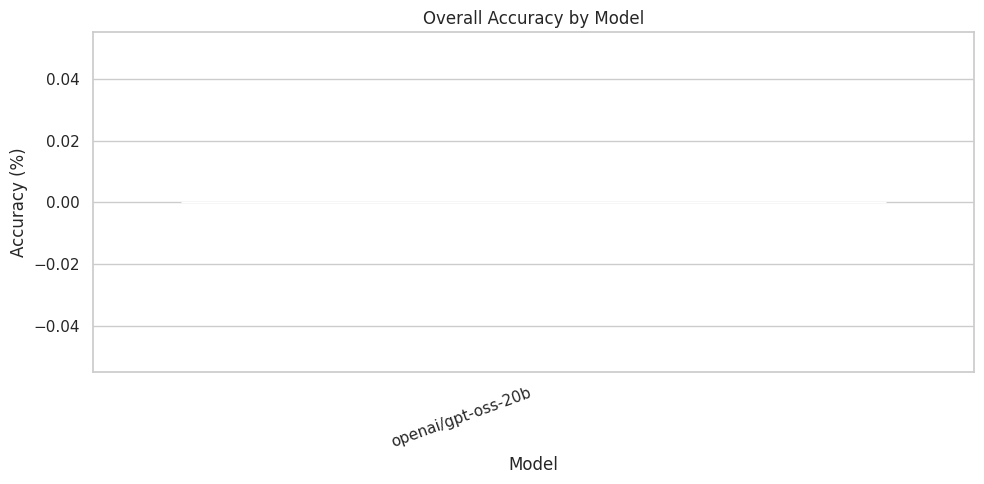

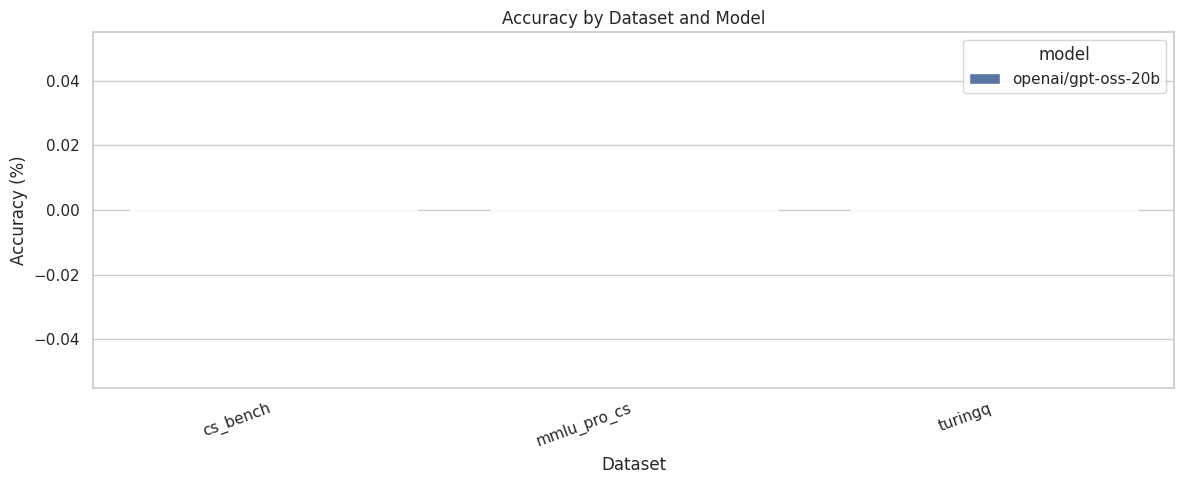

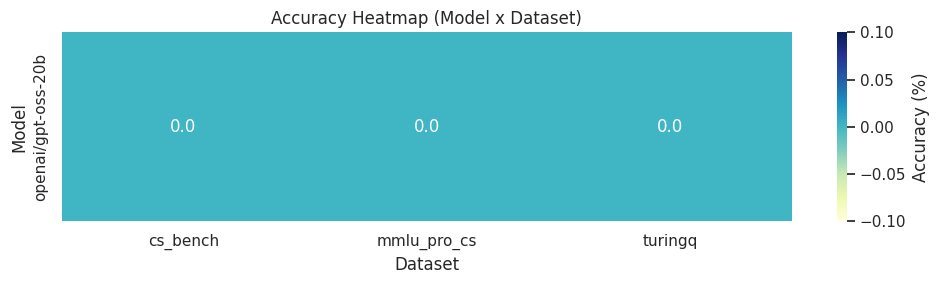

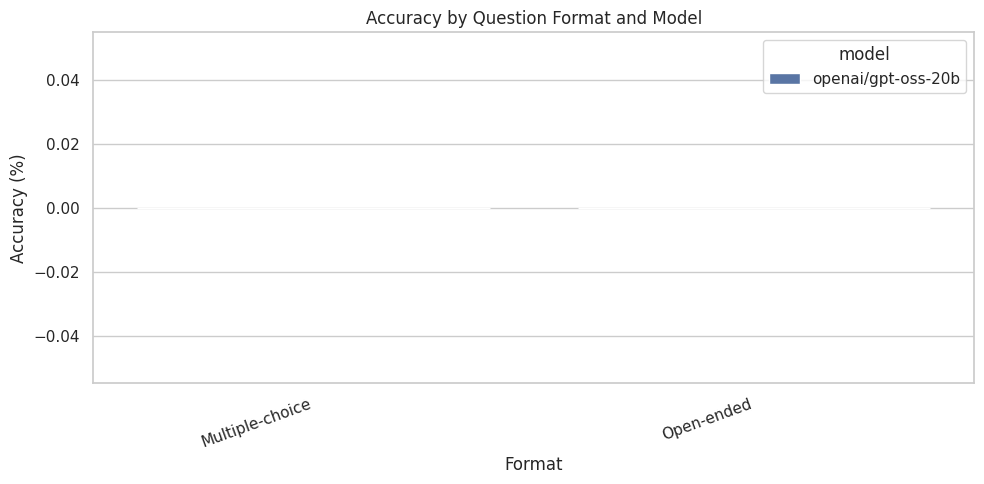

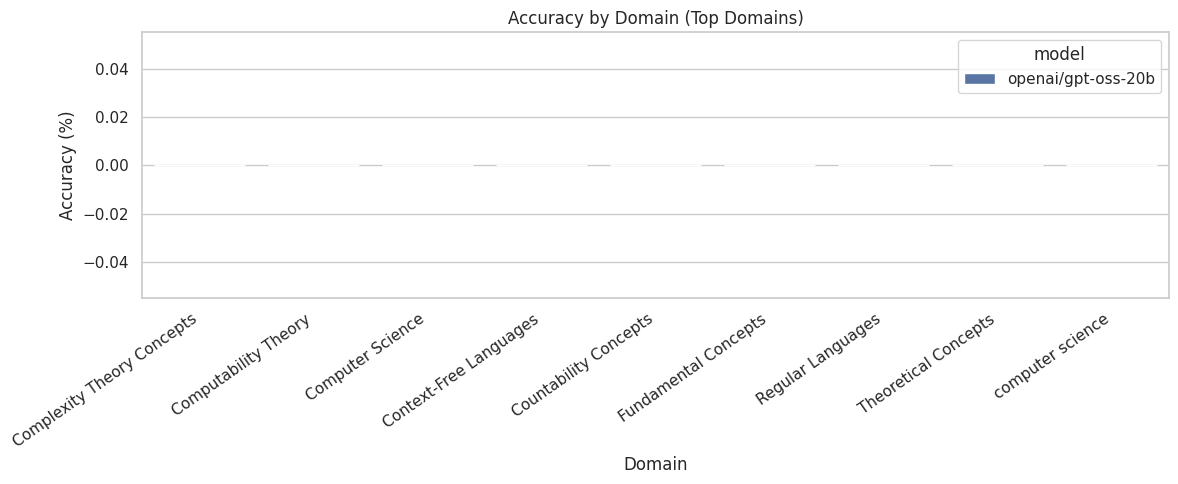

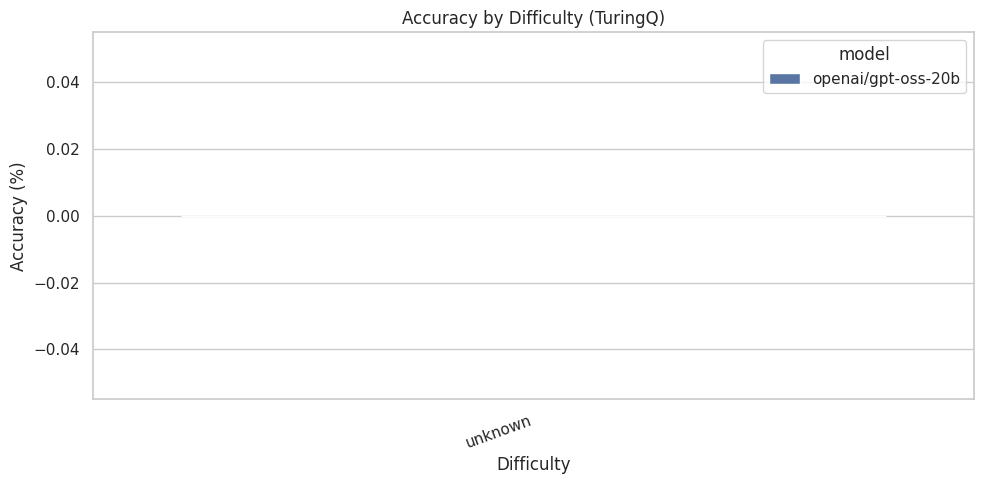

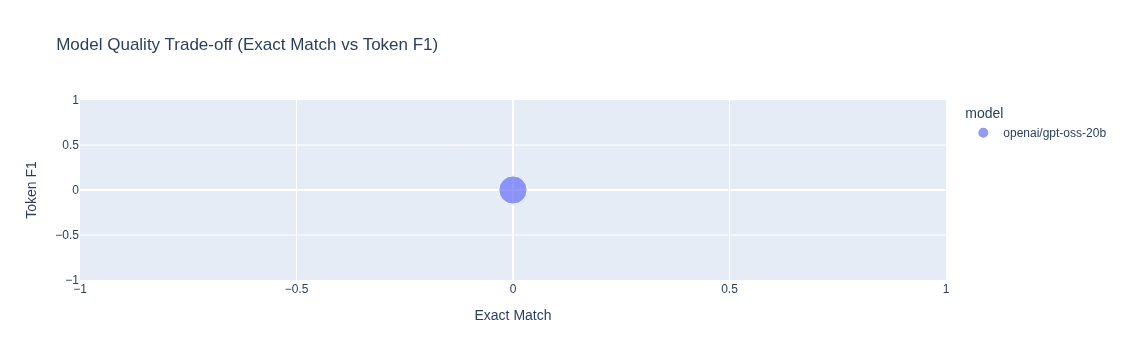

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

if pred_df.empty:
    raise ValueError("No prediction rows available for visualization.")

def _as_percent(df: pd.DataFrame, col: str = "accuracy") -> pd.DataFrame:
    out = df.copy()
    if col in out.columns:
        out[col] = out[col] * 100.0
    return out

# 1) Overall model leaderboard
overall_plot_df = _as_percent(metrics["overall"], "accuracy").sort_values("accuracy", ascending=False)
plt.figure()
sns.barplot(data=overall_plot_df, x="model", y="accuracy", palette="viridis")
plt.title("Overall Accuracy by Model")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# 2) Model x Dataset grouped bars
by_dataset_plot_df = _as_percent(metrics["by_dataset"], "accuracy")
plt.figure(figsize=(12, 5))
sns.barplot(data=by_dataset_plot_df, x="dataset", y="accuracy", hue="model")
plt.title("Accuracy by Dataset and Model")
plt.ylabel("Accuracy (%)")
plt.xlabel("Dataset")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# 3) Heatmap: Model x Dataset accuracy
heat_ds = by_dataset_plot_df.pivot(index="model", columns="dataset", values="accuracy")
plt.figure(figsize=(10, max(3, len(heat_ds) * 0.6)))
sns.heatmap(heat_ds, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "Accuracy (%)"})
plt.title("Accuracy Heatmap (Model x Dataset)")
plt.xlabel("Dataset")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

# 4) Model x Format grouped bars
by_format_plot_df = _as_percent(metrics["by_format"], "accuracy")
plt.figure(figsize=(10, 5))
sns.barplot(data=by_format_plot_df, x="format", y="accuracy", hue="model")
plt.title("Accuracy by Question Format and Model")
plt.ylabel("Accuracy (%)")
plt.xlabel("Format")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# 5) Domain-wise accuracy (top domains by support)
domain_support = pred_df.groupby("domain", as_index=False).size().rename(columns={"size": "count"})
top_domains = domain_support.sort_values("count", ascending=False).head(12)["domain"].tolist()
by_domain_plot_df = _as_percent(metrics["by_domain"], "accuracy")
by_domain_plot_df = by_domain_plot_df[by_domain_plot_df["domain"].isin(top_domains)]
if not by_domain_plot_df.empty:
    plt.figure(figsize=(12, 5))
    sns.barplot(data=by_domain_plot_df, x="domain", y="accuracy", hue="model")
    plt.title("Accuracy by Domain (Top Domains)")
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Domain")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

# 6) TuringQ difficulty breakdown (if available)
by_diff_plot_df = _as_percent(metrics["by_difficulty"], "accuracy")
if not by_diff_plot_df.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=by_diff_plot_df, x="difficulty", y="accuracy", hue="model")
    plt.title("Accuracy by Difficulty (TuringQ)")
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Difficulty")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

# 7) TuringQ type breakdown (if available)
by_type_plot_df = _as_percent(metrics["by_type"], "accuracy")
if not by_type_plot_df.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=by_type_plot_df, x="type", y="accuracy", hue="model")
    plt.title("Accuracy by Question Type (TuringQ)")
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Type")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

# 8) Interactive scatter: EM vs F1 by model
scatter_df = metrics["overall"].copy()
if not scatter_df.empty:
    fig = px.scatter(
        scatter_df,
        x="exact_match",
        y="token_f1",
        size="total",
        color="model",
        hover_data=["accuracy", "total"],
        title="Model Quality Trade-off (Exact Match vs Token F1)",
    )
    fig.update_layout(xaxis_title="Exact Match", yaxis_title="Token F1")
    fig.show()

In [10]:
run_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_dir = Path("./complete_benchmark_reports") / run_tag
out_dir.mkdir(parents=True, exist_ok=True)

pred_df.to_csv(out_dir / "predictions.csv", index=False)
metrics["overall"].to_csv(out_dir / "metrics_overall.csv", index=False)
metrics["by_dataset"].to_csv(out_dir / "metrics_by_dataset.csv", index=False)
metrics["by_format"].to_csv(out_dir / "metrics_by_format.csv", index=False)
metrics["by_domain"].to_csv(out_dir / "metrics_by_domain.csv", index=False)
metrics["by_difficulty"].to_csv(out_dir / "metrics_by_difficulty.csv", index=False)
metrics["by_type"].to_csv(out_dir / "metrics_by_type.csv", index=False)

json_summary = {
    "overall": metrics["overall"].to_dict(orient="records"),
    "by_dataset": metrics["by_dataset"].to_dict(orient="records"),
    "by_format": metrics["by_format"].to_dict(orient="records"),
    "by_domain": metrics["by_domain"].to_dict(orient="records"),
    "by_difficulty": metrics["by_difficulty"].to_dict(orient="records"),
    "by_type": metrics["by_type"].to_dict(orient="records"),
}
with open(out_dir / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(json_summary, f, ensure_ascii=False, indent=2)

print(f"Saved all benchmark reports to: {out_dir.resolve()}")

Saved all benchmark reports to: /media/sasank-v/New Volume/Studies/College/Interships/LLM-Finetuning/notebooks/benchmark/complete_benchmark_reports/20260322_184540
